In [ ]:
# !pip install dowhy==0.12 econml==0.16

In [1]:
import numpy as np
import pandas as pd

import econml
import dowhy
from dowhy import CausalModel

import networkx as nx

from sklearn.ensemble import GradientBoostingRegressor

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

C:\Users\aleks\anaconda3\envs\causal_book_py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Causal Inference Under Hidden Confounding
Making Decisions When We Know Less Than We’d Like to

ML Summit July 2025

<img src="img/ml-summit.png" width=500 align="left">

<br><br><br><br><br><br><br><br><br><br>


## ‼️Free Resources For You

❤️ [CausalPython](https://causalpython.io) - FREE newsletter

❤️ [Causal Secrets](https://causalsecrets.com/) - FREE mini-course on causality

<a href="https://causalpython.io"><img src="img/CausalPython.io__flat.png" width=150 align="left"></a>
<br>



In [15]:
# Read the data
data = pd.read_csv('data/market_data.csv').sample(1000)

In [38]:
data.head()

In [39]:
plt.figure(figsize=(15, 4))

plt.subplot(121)
plt.hist(data['ad_spend'], bins=50)
plt.xlabel('Ad spend')

plt.subplot(122)
plt.hist(data['sales'], bins=50)
plt.xlabel('Sales')

plt.show()

In [40]:
print('True effect = 0.17')

In [19]:
# Instantiate the graph
graph = nx.DiGraph()

# Add edges
graph.add_edges_from(
    [
        ('ad_spend', 'sales'),
        ('holiday', 'ad_spend'),
        ('holiday', 'sales'),
        ('x1', 'ad_spend'),
        ('x2', 'ad_spend'),
        ('x3', 'ad_spend'),
        ('x1', 'sales'),
        ('x2', 'sales'),
        ('x3', 'sales'),
        ('geo_B', 'sales'),
        ('geo_C', 'sales'),
        ('geo_B', 'ad_spend'),
        ('geo_C', 'ad_spend'),
    ]
)

In [41]:
nx.draw(
    graph,
    with_labels=True,
    node_size=4000,
    font_color='white'
)

In [29]:
# Drop W0 -> unobserved confounder
dropped_cols = ['geo_B', 'geo_C']
user_data = data.drop(dropped_cols, axis=1)


In [42]:
user_data.head()

In [31]:
# Instantiate the graph
user_graph = nx.DiGraph()

# Add edges
user_graph.add_edges_from(
    [
        ('ad_spend', 'sales'),
        ('holiday', 'ad_spend'),
        ('holiday', 'sales'),
        ('x1', 'ad_spend'),
        ('x2', 'ad_spend'),
        ('x3', 'ad_spend'),
        ('x1', 'sales'),
        ('x2', 'sales'),
        ('x3', 'sales'),
    ]
)

In [43]:
# Define the causal model
model = CausalModel(
    data=user_data,
    treatment='ad_spend',
    outcome='sales',
    graph=user_graph
)

model.view_model()

In [44]:
# Get the estimand
estimand = model.identify_effect()
print(estimand)

In [45]:
# Estimate the effect
linear_dml_estimate = model.estimate_effect(
    estimand,
    method_name="backdoor.econml.dml.dml.LinearDML",
    method_params={
        'init_params': {'model_y': GradientBoostingRegressor(),
                        'model_t': GradientBoostingRegressor(),
                        'linear_first_stages': False
                        },
        'fit_params': {'cache_values': True,}
        })

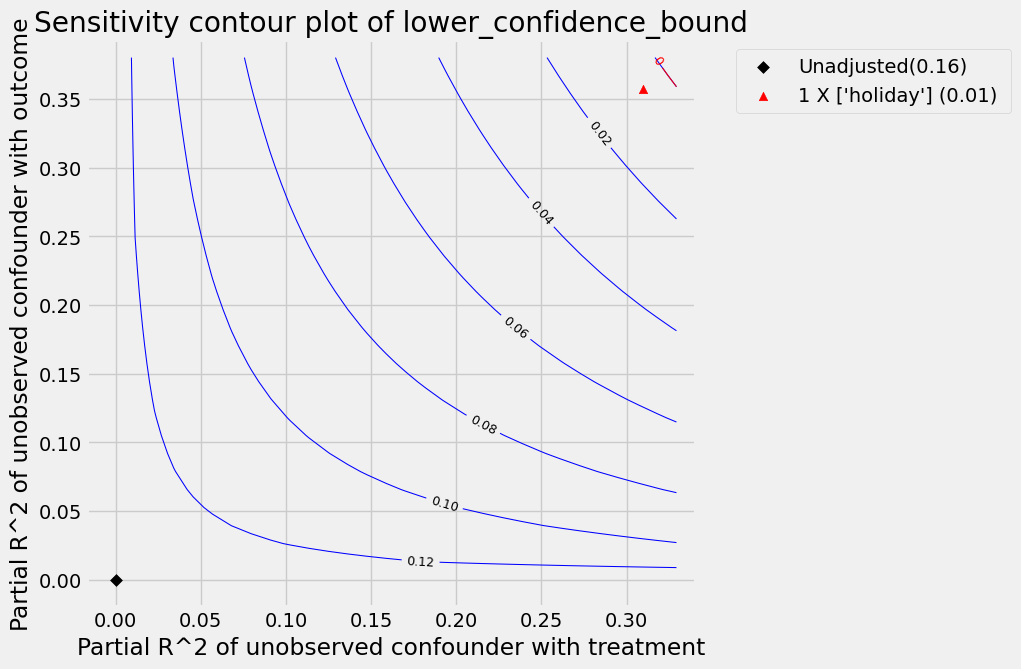

In [36]:
refute_bm = model.refute_estimate(
    estimand,
    linear_dml_estimate,
    method_name='add_unobserved_common_cause',
    simulation_method='non-parametric-partial-R2',
    benchmark_common_causes=['holiday'],
    effect_fraction_on_treatment=1,
    effect_fraction_on_outcome=1
)

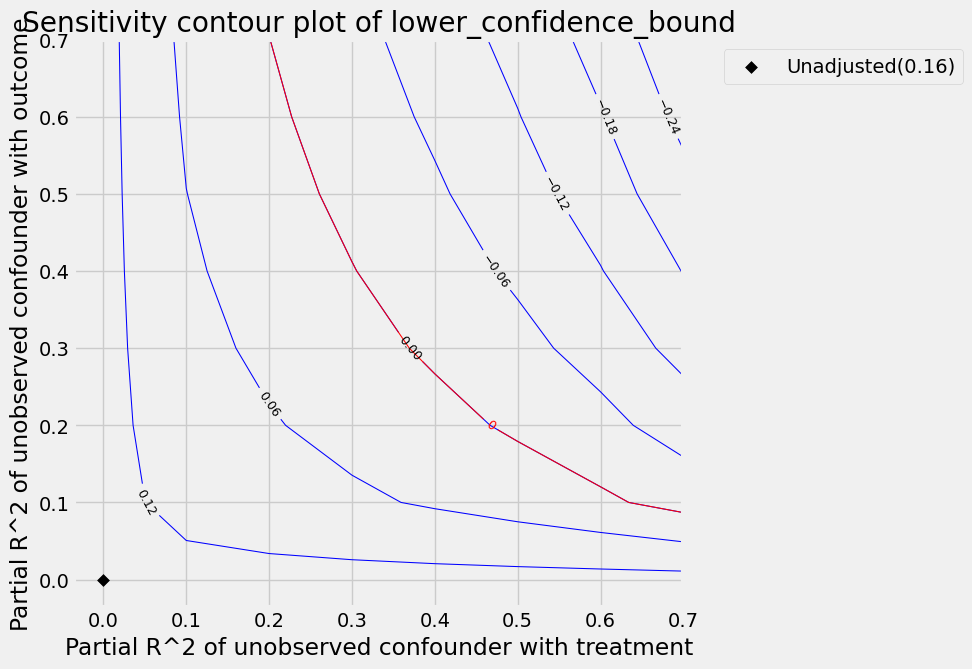

Sensitivity Analysis to Unobserved Confounding using partial R^2 parameterization

Original Effect Estimate : 0.15986590404227607
Robustness Value : 0.39

Robustness Value (alpha=0.05) : 0.35000000000000003

Interpretation of results :
Any confounder explaining less than 39.0% percent of the residual variance of both the treatment and the outcome would not be strong enough to explain away the observed effect i.e bring down the estimate to 0 

For a significance level of 5.0%, any confounder explaining more than 35.0% percent of the residual variance of both the treatment and the outcome would be strong enough to make the estimated effect not 'statistically significant'




In [37]:
# Sensitivity refuter
refutation_sensitivity = model.refute_estimate(
    estimand,
    linear_dml_estimate,
    method_name='add_unobserved_common_cause',
    simulation_method='non-parametric-partial-R2',
    partial_r2_confounder_treatment=np.arange(0, 0.8, 0.1),
    partial_r2_confounder_outcome=np.arange(0, 0.8, 0.1)
    )
print(refutation_sensitivity)

[DoWhy Sensitivity Module Documentation](https://www.pywhy.org/dowhy/v0.10/example_notebooks/sensitivity_analysis_nonparametric_estimators.html)